# Heart Disease NUTS Model

In [22]:
import numpy as np
import pandas as pd

import pymc as pm
import arviz as az

import matplotlib.pyplot as plt

DATA_PATH = "../data/heart-disease/heart.csv"
df = pd.read_csv(DATA_PATH)
df.head()
df.shape

(1025, 14)

In [23]:
# Identify the target column name (common ones: "target", "output", "HeartDisease")
df.columns


predictors = ["sex", "age", "thalach", "ca", "chol"]
target_col = "target"

data = df[predictors + [target_col]].dropna().copy()

y = (df["target"] == 0).astype(int).to_numpy()   # disease=1, healthy=0
X_raw = data[predictors].to_numpy()


In [24]:
X = X_raw.astype(float).copy()

means = X.mean(axis=0)
stds  = X.std(axis=0)
Xz = (X - means) / stds

feature_names = predictors
Xz[:5], y[:5]


(array([[ 0.66150409, -0.26843658,  0.82132052,  1.20922066, -0.65933209],
        [ 0.66150409, -0.15815703,  0.2559679 , -0.73197147, -0.83386117],
        [ 0.66150409,  1.71659547, -1.04869198, -0.73197147, -1.39623266],
        [ 0.66150409,  0.72407944,  0.51689988,  0.23862459, -0.83386117],
        [-1.51170646,  0.834359  , -1.87497657,  2.17981673,  0.93082177]]),
 array([1, 1, 1, 1, 1]))

In [25]:
with pm.Model() as model:
    X_data = pm.Data("X", Xz)
    y_data = pm.Data("y", y)

    # Priors: regularizing normals
    alpha = pm.Normal("alpha", mu=0.0, sigma=1.5)                 # intercept
    beta  = pm.Normal("beta", mu=0.0, sigma=1.0, shape=Xz.shape[1])  # slopes

    logits = alpha + pm.math.dot(X_data, beta)
    p = pm.Deterministic("p", pm.math.sigmoid(logits))

    obs = pm.Bernoulli("obs", p=p, observed=y_data)

    idata = pm.sample(
        draws=50000,
        tune=50000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

summary = az.summary(
    idata,
    var_names=["alpha", "beta"],
    hdi_prob=0.94
)
summary

beta_summary = summary.loc[[f"beta[{i}]" for i in range(len(feature_names))]].copy()
beta_summary["feature"] = feature_names
beta_summary = beta_summary.set_index("feature")

# Credibly different from zero if 0 is outside the HDI interval
beta_summary["credible_nonzero"] = ~(
    (beta_summary["hdi_3%"] <= 0.0) & (beta_summary["hdi_97%"] >= 0.0)
)

beta_summary.sort_values("credible_nonzero", ascending=False)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 50_000 tune and 50_000 draw iterations (200_000 + 200_000 draws total) took 110 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,credible_nonzero
feature,,,,,,,,,,
sex,0.781,0.087,0.619,0.945,0.0,0.0,231878.0,152306.0,1.0,True
thalach,-1.031,0.098,-1.215,-0.848,0.0,0.0,229878.0,162449.0,1.0,True
ca,0.779,0.090,0.606,0.947,0.0,0.0,255692.0,157580.0,1.0,True
chol,0.406,0.082,0.253,0.562,0.0,0.0,234301.0,162353.0,1.0,True
age,0.079,0.088,-0.088,0.244,0.0,0.0,237089.0,164579.0,1.0,False


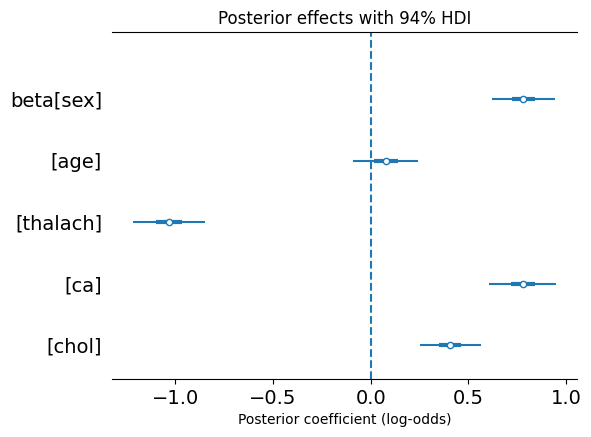

In [26]:
beta_dim = idata.posterior["beta"].dims[-1]
idata = idata.assign_coords({beta_dim: feature_names})
idata.posterior["beta"] = idata.posterior["beta"].rename({beta_dim: "feature"})

az.plot_forest(
    idata,
    var_names=["beta"],
    coords={"feature": feature_names},
    combined=True,
    hdi_prob=0.94
)

plt.axvline(0, linestyle="--")
plt.xlabel("Posterior coefficient (log-odds)")
plt.title("Posterior effects with 94% HDI")
plt.show()
